## **Проектная работа №1: Классификация объектов на изображении**

### **Цель:**

Разработать программу на Python, которая принимает на вход фотографию с изображением монет и вычисляет общую сумму денежных средств, отображенных на ней, используя только библиотеку OpenCV и стандартные библиотеки Python.

### **Базовая реализация:**

1. **Сбор изображения:**
   - Используйте камеру или загрузите готовое изображение с монетами для обработки.

2. **Предварительная обработка изображения:**
   - Преобразуйте изображение в оттенки серого.
   - Примените размытие Гаусса для уменьшения шума.
   - Используйте оператор Кэнни для обнаружения краев.

3. **Обнаружение кругов (монет):**
   - Используйте преобразование Хафа для обнаружения кругов на изображении.
   - Получите координаты центров и радиусов обнаруженных кругов (монет).

4. **Классификация монет:**
   - Определите номинал каждой монеты на основе ее радиуса.
   - Установите пороговые значения для радиусов, соответствующие разным номиналам:
     - **Маленький радиус:** 1 рубль.
     - **Средний радиус:** 2 рубля.
     - **Большой радиус:** 5 рублей.

5. **Подсчет общей суммы:**
   - Суммируйте номиналы всех обнаруженных монет.
   - Отобразите общую сумму на изображении или в консоли.

6. **Отображение результатов:**
   - Нарисуйте окружности на изображении вокруг обнаруженных монет.
   - Подпишите рядом с каждой монетой ее номинал.
   - Покажите исходное изображение с отмеченными монетами.
   - Выведите обработанные этапы для визуализации процесса (например, изображение после предварительной обработки, с контурами и т.д.).

### **Требования к реализации:**

- Использовать только библиотеку **OpenCV** и стандартные библиотеки Python (например, **NumPy**).
- Код должен быть хорошо документирован с комментариями для каждого основного блока.
- Предусмотреть возможность настройки параметров обработки через трекбары или отдельные переменные.


### **Рекомендации:**

- **Преобразование Хафа** для кругов является удобным инструментом для обнаружения круглых объектов на изображении.
- **Пороговые значения радиусов** необходимо подобрать экспериментально, протестировав на образцах монет разных номиналов.
- **Обработка перекрывающихся монет** может потребовать более сложных алгоритмов, таких как водоразделение или использование градиентных признаков.
- Тестируйте программу на различных изображениях с разным количеством и расположением монет, а также при разном освещении.

### **Ожидаемый результат:**

В результате выполнения задания вы получите программу, которая способна:

- Принимать на вход изображение с монетами.
- Обрабатывать изображение и обнаруживать монеты без использования библиотеки cvzone.
- Определять номинал каждой монеты на основе ее радиуса или других признаков.
- Вычислять и отображать общую сумму монет на изображении.

---

**Пример использования программы:**

- Пользователь запускает программу.
- Загружается изображение с монетами.
- Программа обрабатывает изображение, отмечает каждую монету и подписывает ее номинал.
- Отображается изображение с результатами и выводится общая сумма, например: **"Общая сумма: 37 рублей"**.

---

**Заметка:**

Данный проект позволит вам:

- Изучить и применить технологии обработки изображений с помощью OpenCV без привлечения сторонних библиотек.
- Научиться решать практические задачи компьютерного зрения, применяя базовые методы и улучшая их по мере необходимости.

---

**Советы по реализации:**

- **Настройка параметров:**
  - Для преобразования Хафа используйте функцию `cv2.HoughCircles()`.
  - Экспериментируйте с параметрами `dp`, `minDist`, `param1`, `param2`, `minRadius`, `maxRadius`.
- **Отображение результатов:**
  - Используйте функцию `cv2.circle()` для рисования окружностей.
  - Для отображения текста воспользуйтесь `cv2.putText()`.
- **Обработка ошибок:**
  - Обрабатывайте случаи, когда преобразование Хафа не обнаруживает ни одной монеты.
  - Предусмотрите проверку входных данных и вывод информативных сообщений для пользователя.



In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import requests

In [ ]:
# Ссылка на файл для скачивания
url1 = r'https://shmalakskoe-r73.gosweb.gosuslugi.ru/netcat_files/31/112/4197b1.jpg'
url2 = r'https://cdn.monetnik.ru/storage/market-lot/42/67/745542/2628117_mainViewLot_2x.jpg'

# Скачиваем файл с помощью wget
!wget -O money1.jpg '{url1}'
!wget -O money2.jpg '{url2}'

# Ссылка на файл для скачивания
url3 = r'https://ic.pics.livejournal.com/mikhaelis2009/81361900/175805/175805_900.jpg'

# Скачиваем файл с помощью wget
!wget -O money3.jpg '{url3}'

--2025-10-26 14:42:55--  https://shmalakskoe-r73.gosweb.gosuslugi.ru/netcat_files/31/112/4197b1.jpg
Resolving shmalakskoe-r73.gosweb.gosuslugi.ru (shmalakskoe-r73.gosweb.gosuslugi.ru)... 109.207.1.46
Connecting to shmalakskoe-r73.gosweb.gosuslugi.ru (shmalakskoe-r73.gosweb.gosuslugi.ru)|109.207.1.46|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 802358 (784K) [image/jpeg]
Saving to: ‘money1.jpg’

money1.jpg          100%[===================>] 783.55K   519KB/s    in 1.5s    

2025-10-26 14:42:57 (519 KB/s) - ‘money1.jpg’ saved [802358/802358]

--2025-10-26 14:42:57--  https://cdn.monetnik.ru/storage/market-lot/42/67/745542/2628117_mainViewLot_2x.jpg
Resolving cdn.monetnik.ru (cdn.monetnik.ru)... 88.210.36.195
Connecting to cdn.monetnik.ru (cdn.monetnik.ru)|88.210.36.195|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115200 (112K) [image/jpeg]
Saving to: ‘money2.jpg’

money2.jpg          100%[===================>] 112.50K  --.-KB/s  

In [ ]:
def normalize_image(image, target_size=(1024, 1024)):
    """
    Нормализует изображение до заданного размера (например, 1024x1024), сохраняя пропорции.
    Если изображение не соответствует целевому размеру, добавляется чёрное заполнение.

    Parameters:
        image: входное изображение (numpy array, загруженное, например, через cv.imread)
        target_size: кортеж (ширина, высота) для итогового изображения

    Returns:
        normalized_image: изображение размером target_size
    """

    # Получаем размеры исходного изображения
    h, w = image.shape[:2]
    target_w, target_h = target_size

    # Вычисляем соотношение сторон
    aspect_ratio = w / h
    target_aspect_ratio = target_w / target_h

    # Вычисляем масштаб для сохранения пропорций
    if aspect_ratio > target_aspect_ratio:
        # Изображение шире, чем нужно: масштабируем по ширине
        scale = target_w / w
    else:
        # Изображение выше, чем нужно: масштабируем по высоте
        scale = target_h / h

    # Новые размеры с учётом масштаба
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Масштабируем изображение
    resized_image = cv.resize(image, (new_w, new_h), interpolation=cv.INTER_CUBIC)

    # Создаём пустое изображение 1024x1024 (чёрный фон)
    normalized_image = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    # Вычисляем координаты для центрирования изображения
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2

    # Вставляем масштабированное изображение в центр
    normalized_image[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_image

    return normalized_image

In [ ]:
image_path1 = 'money1.jpg'
image_path2 = 'money2.jpg'
image_path3 = 'money3.jpg'

image3 = cv.imread(image_path3)

normal_image3 = normalize_image(image3)

image1 = cv.imread(image_path1)
image2 = cv.imread(image_path2)

cv2_imshow(image1)
cv2_imshow(image2)

In [ ]:
image = image1

In [ ]:
def func_circl(image):
  # Преобразование в градации серого
  gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

  # Размытие изображения для уменьшения шума
  gray_blurred = cv.medianBlur(gray, 5)

  # Параметры для функции HoughCircles
  dp = 1.2                # Параметр разрешения аккумуляторного массива
  minDist = 125            # Минимальное расстояние между центрами обнаруженных окружностей
  param1 = 50             # Порог для метода Кэнни
  param2 = 165            # Порог для функции HoughCircles (чем меньше, тем больше ложных кругов)
  minRadius = 20         # Минимальный радиус круга
  maxRadius = 250          # Максимальный радиус круга

  # Обнаружение кругов
  circles = cv.HoughCircles(gray_blurred, cv.HOUGH_GRADIENT, dp, minDist,
                            param1=param1, param2=param2,
                            minRadius=minRadius, maxRadius=maxRadius)

  # Создание копии изображения для отображения результатов
  img_circles = image.copy()

  # Проверка, найдены ли круги
  if circles is not None:
      # Округление координат центров и радиусов до целых чисел
      circles = np.uint16(np.around(circles))
      for circle in circles[0, :]:
          center = (circle[0], circle[1])  # Координаты центра
          radius = circle[2]              # Радиус
          # Рисование контура круга
          cv.circle(img_circles, center, radius, (0, 255, 0), 2)
      return gray_blurred, img_circles
  else:
      print("Круги не найдены")

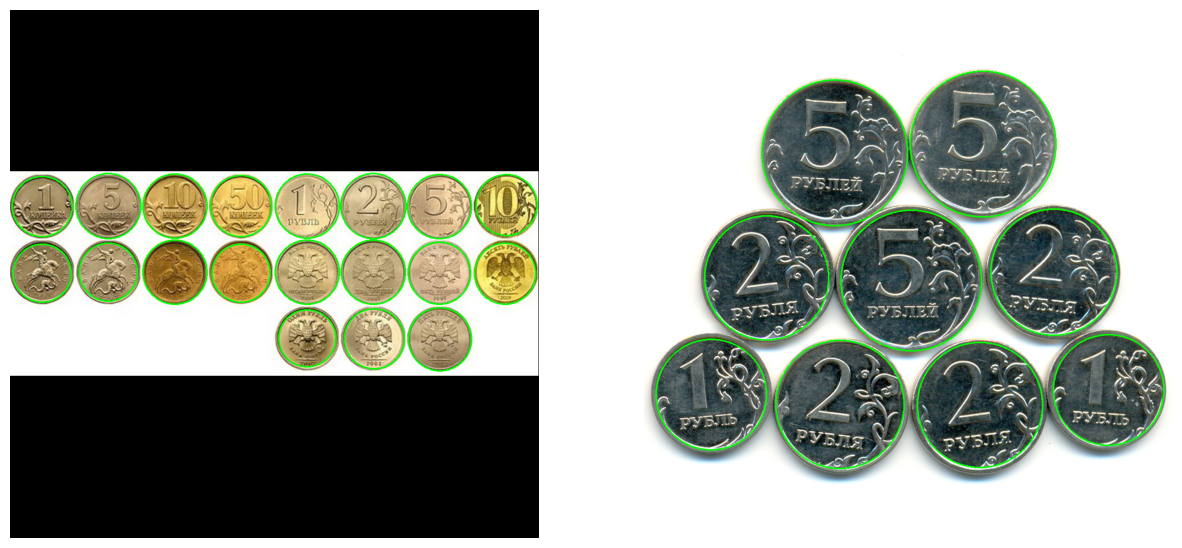

In [ ]:
gray_blurred, img_circles = func_circl(normal_image3)

plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_circles, cv.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')

gray_blurred, img_circles = func_circl(normalize_image(image1))

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_circles, cv.COLOR_BGR2RGB), cmap='gray')
plt.axis('off')
plt.show()

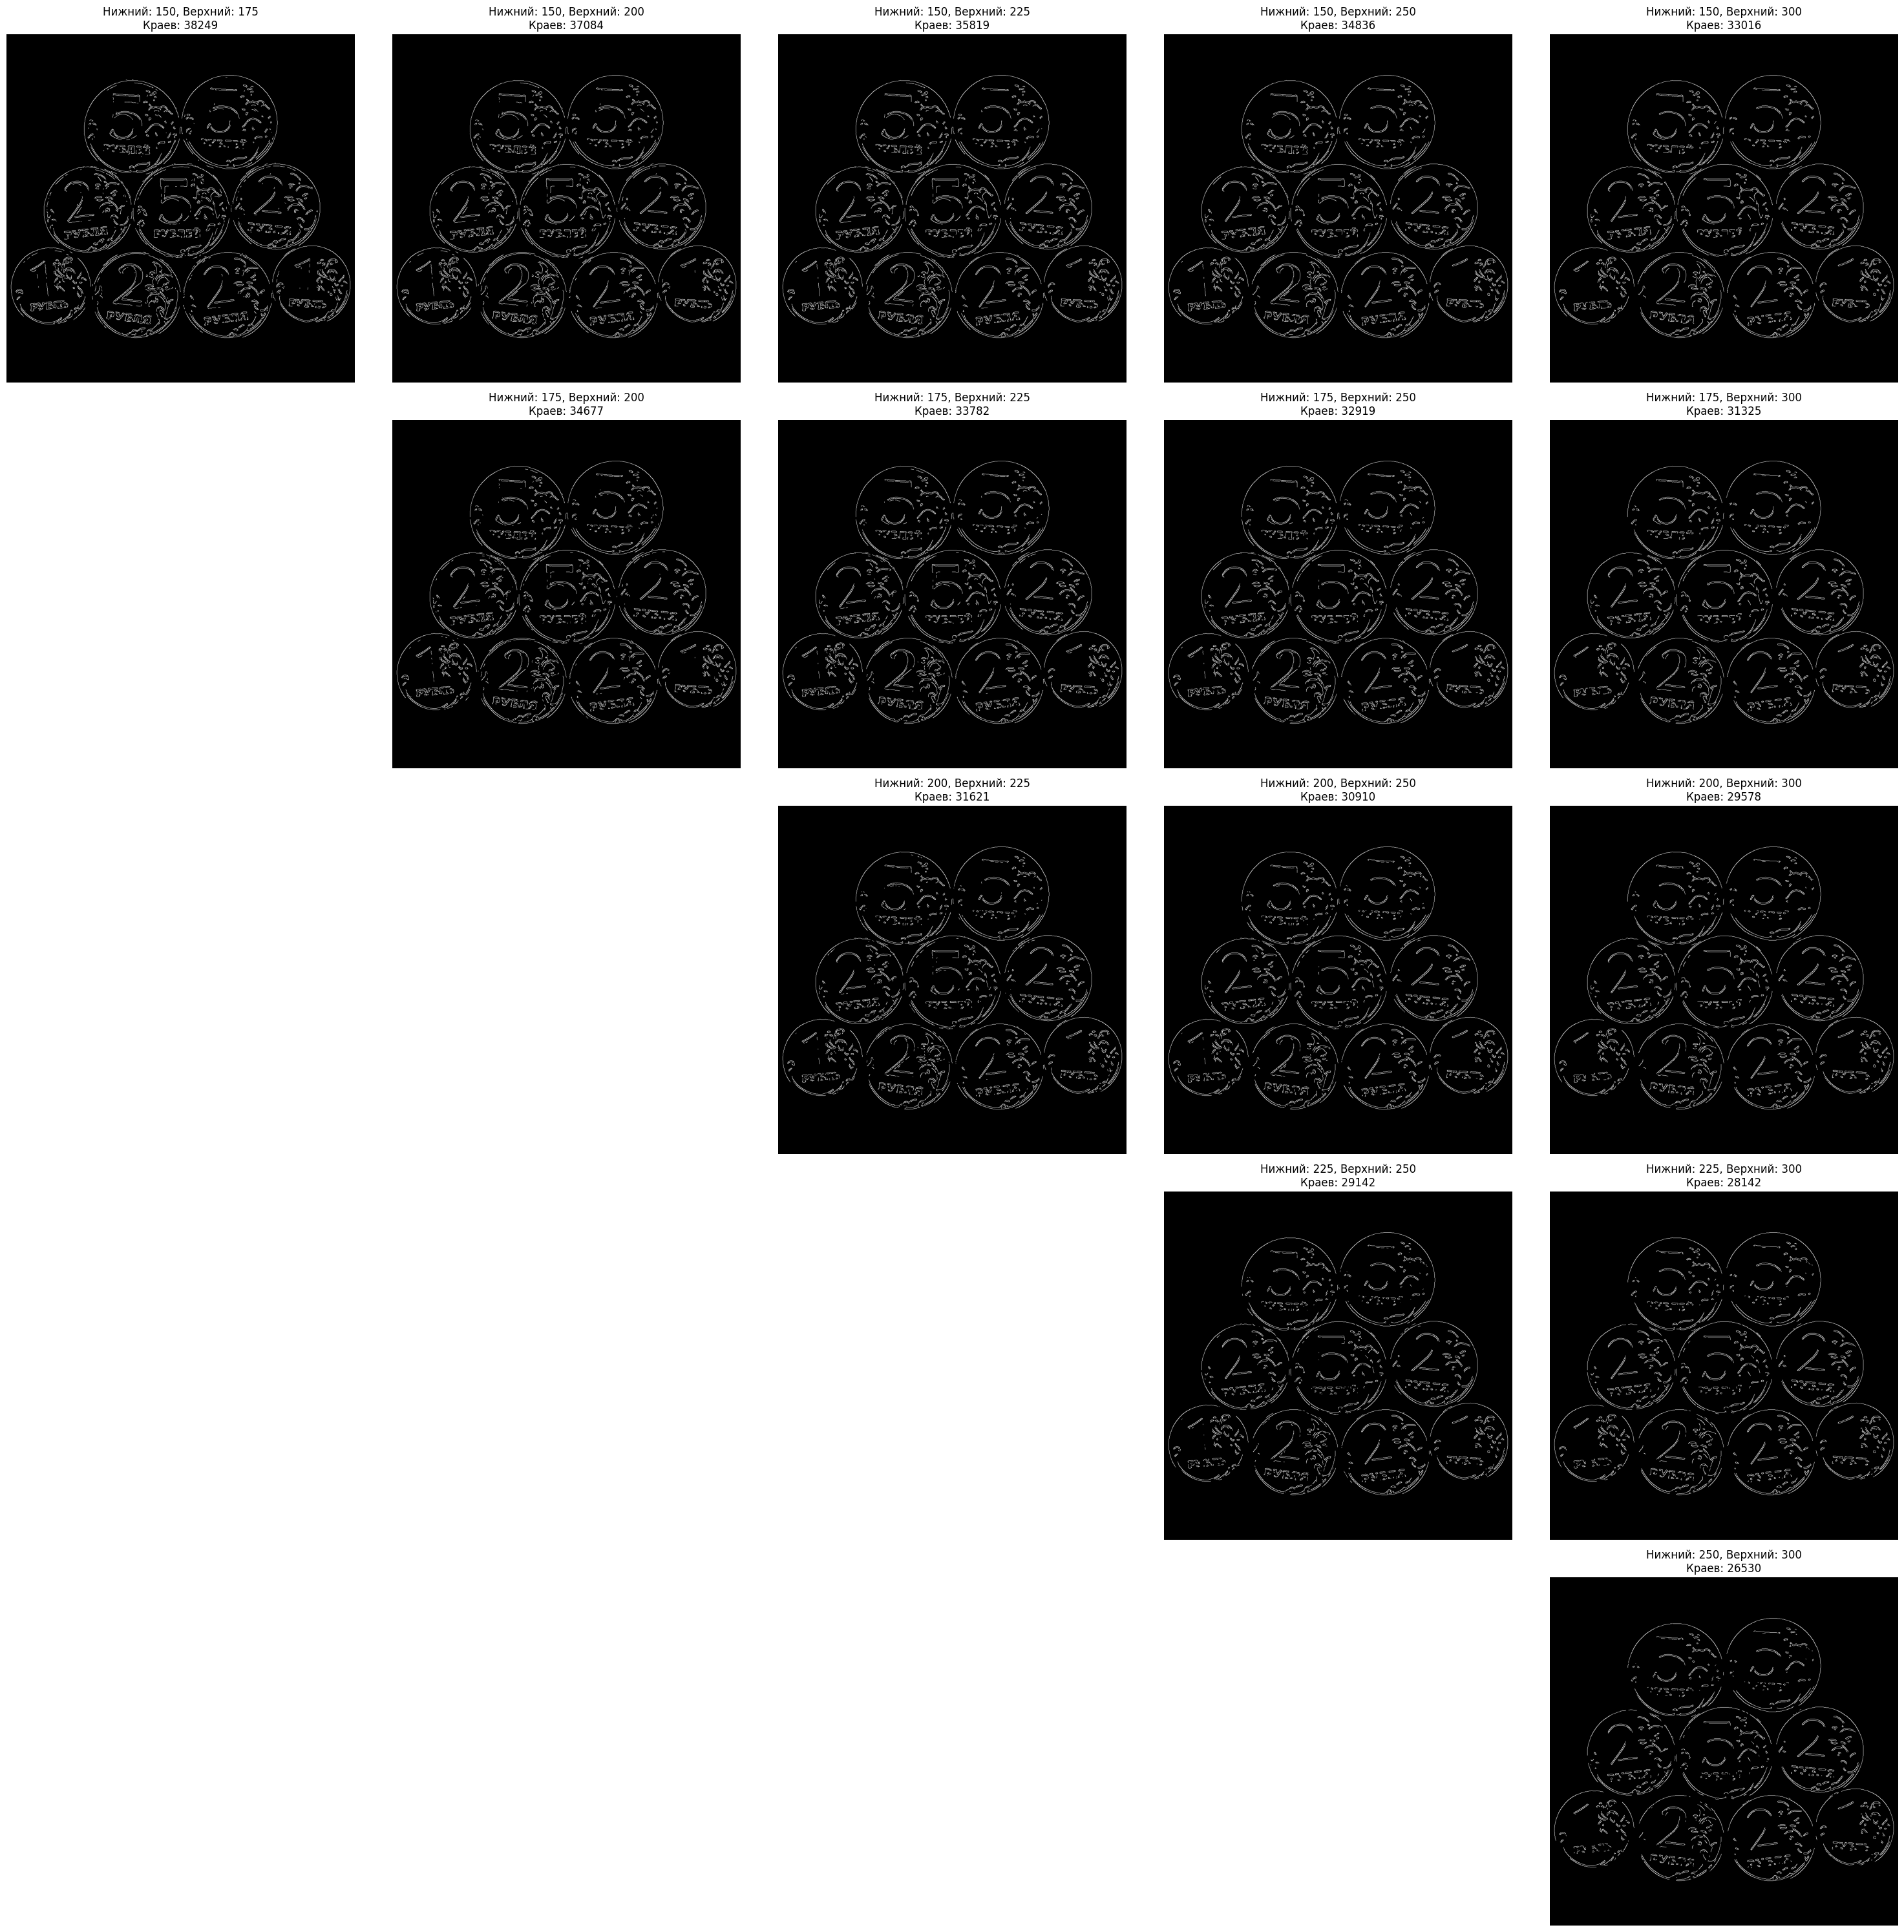

In [ ]:
low_thresholds = [150, 175, 200, 225, 250]  # Нижние пороги
high_thresholds = [175, 200, 225, 250, 300] # Верхние пороги

# Количество строк и столбцов для визуализации
cols = len(high_thresholds)
rows = len(low_thresholds)

# Создаем фигуру для отображения
plt.figure(figsize=(cols * 6, rows * 6))

# Список для хранения метрик и соответствующих порогов
results = []

# Перебираем все комбинации порогов
for i, low_th in enumerate(low_thresholds, start=1):
    for j, high_th in enumerate(high_thresholds):
        # Пропускаем случаи, где нижний порог больше или равен верхнему
        if low_th >= high_th:
            continue

        # Применяем Canny с текущей парой порогов
        edges = cv.Canny(gray_blurred, low_th, high_th, apertureSize=3)

        # Подсчитываем количество ненулевых пикселей (краев) как метрику
        edge_count = np.count_nonzero(edges)
        results.append((low_th, high_th, edge_count))

        # Визуализация
        plt.subplot(rows, cols, (i - 1) * cols + j + 1)
        plt.imshow(edges, cmap='gray')
        plt.title(f'Нижний: {low_th}, Верхний: {high_th}\nКраев: {edge_count}', fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()

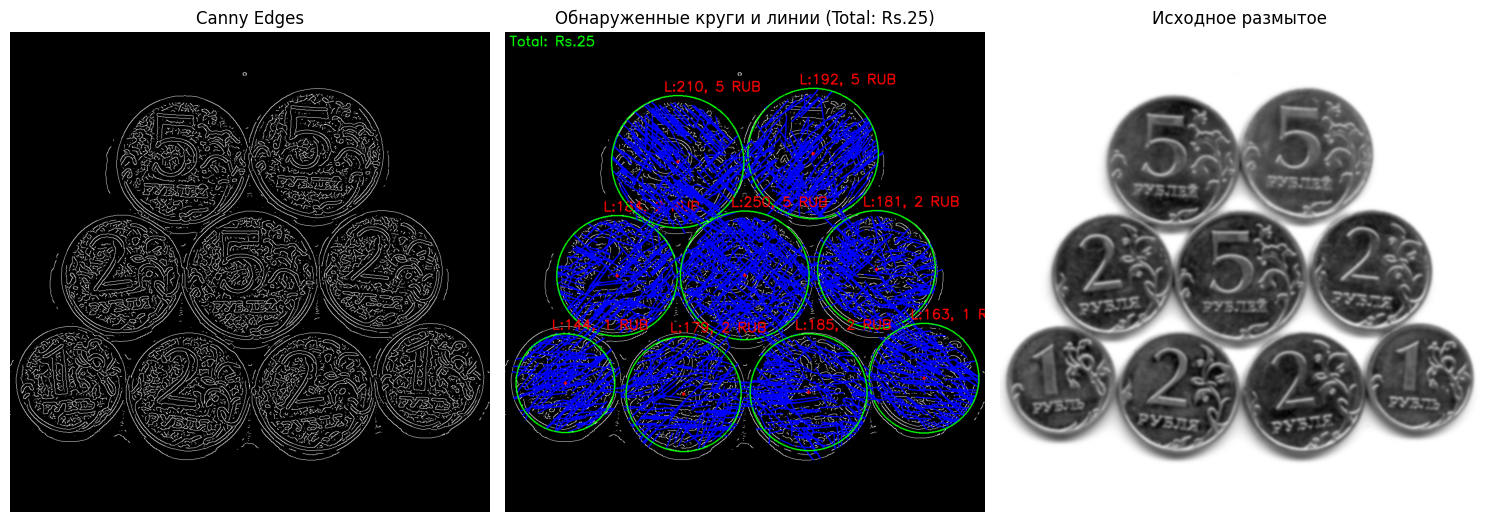

In [ ]:
def my_func(image):
    # Преобразование в градации серого
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Размытие изображения для уменьшения шума
    gray_blurred = cv.GaussianBlur(gray, (15, 15), 0)

    # Параметры для функции HoughCircles
    dp = 1.2
    minDist = 125
    param1 = 50
    param2 = 165
    minRadius = 20
    maxRadius = 250

    # Обнаружение кругов
    circles = cv.HoughCircles(gray_blurred, cv.HOUGH_GRADIENT, dp, minDist,
                              param1=param1, param2=param2,
                              minRadius=minRadius, maxRadius=maxRadius)

    # Создание копии изображения для отображения результатов
    img_circles = image.copy()

    edges = cv.Canny(gray_blurred, 50, 100, apertureSize=7)
    lines = cv.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=30,
        maxLineGap=10
    )

    # Создаём копию для визуализации
    img_result = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # Счётчики линий в кругах и сумма денег
    circle_line_counts = []
    totalMoney = 0

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i, circle in enumerate(circles[0, :]):
            center = (circle[0], circle[1])
            radius = circle[2]
            count = 0

            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    # Центр отрезка
                    mid_x = (x1 + x2) / 2
                    mid_y = (y1 + y2) / 2

                    # Расстояние от центра отрезка до центра круга
                    dist = np.sqrt((mid_x - center[0])**2 + (mid_y - center[1])**2)

                    # Если центр отрезка внутри круга — считаем линию "в круге"
                    if dist <= radius:
                        count += 1
                        # Рисуем линию внутри круга
                        cv.line(img_result, (x1, y1), (x2, y2), (255, 0, 0), 2)

            circle_line_counts.append(count)

            # Классификация монет по количеству линий
            if count <= 163:
                denomination = "1 RUB"
                totalMoney += 1
            elif count >= 192:
                denomination = "5 RUB"
                totalMoney += 5
            else:
                denomination = "2 RUB"
                totalMoney += 2

            # Отрисовка круга
            cv.circle(img_result, center, radius, (0, 255, 0), 2)
            cv.circle(img_result, center, 2, (0, 0, 255), 3)

            # Отрисовка текста с количеством линий и номиналом
            cv.putText(
                img_result,
                f'L:{count}, {denomination}',
                (center[0] - 30, center[1] - radius - 10),
                cv.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 0, 255),
                2
            )

        # Отрисовка общей суммы
        cv.putText(
            img_result,
            f'Total: Rs.{totalMoney}',
            (10, 30),
            cv.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )

        return edges, img_result, gray_blurred, totalMoney
    else:
        print("Круги не найдены")
        return edges, img_result, gray_blurred, totalMoney

# Вызов функции
edges, img_result, gray_blurred, totalMoney = my_func(image)

# Визуализация
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f'Обнаруженные круги и линии (Total: Rs.{totalMoney})')
plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Исходное размытое')
plt.imshow(gray_blurred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

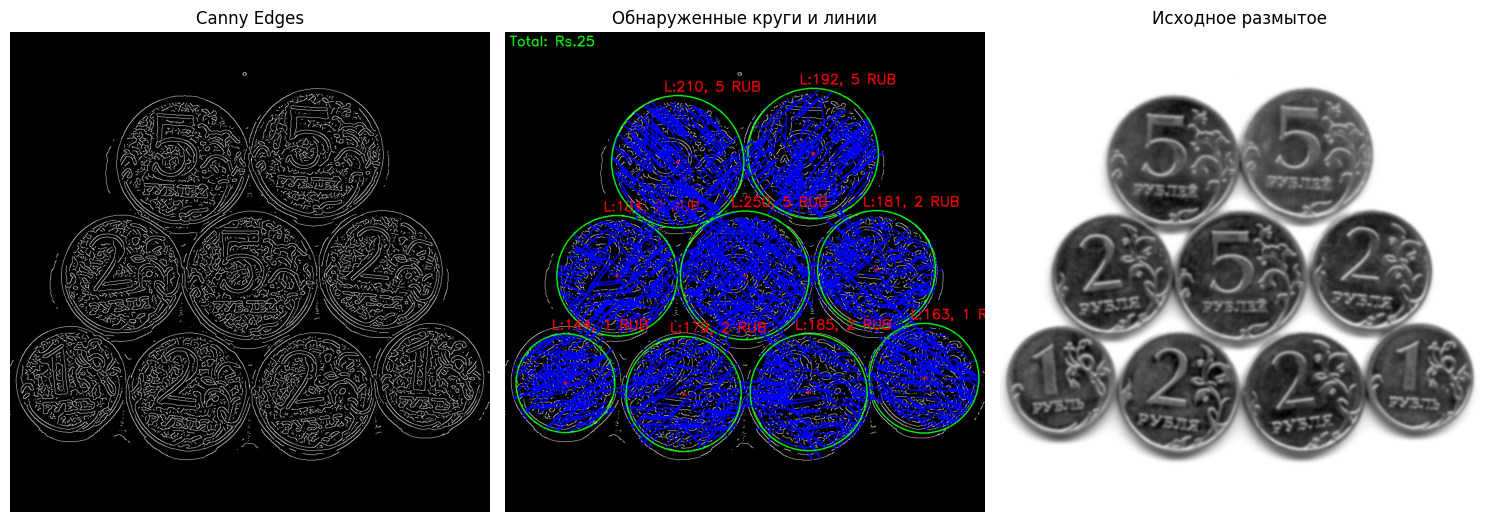

In [ ]:
edges, img_result, gray_blurred, totalMoney = my_func(image)

# Визуализация
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Обнаруженные круги и линии')
plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Исходное размытое')
plt.imshow(gray_blurred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)


gray_blur = cv.GaussianBlur(gray, (15, 15), 0)
binary = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
cv.THRESH_BINARY_INV, 11, 1)

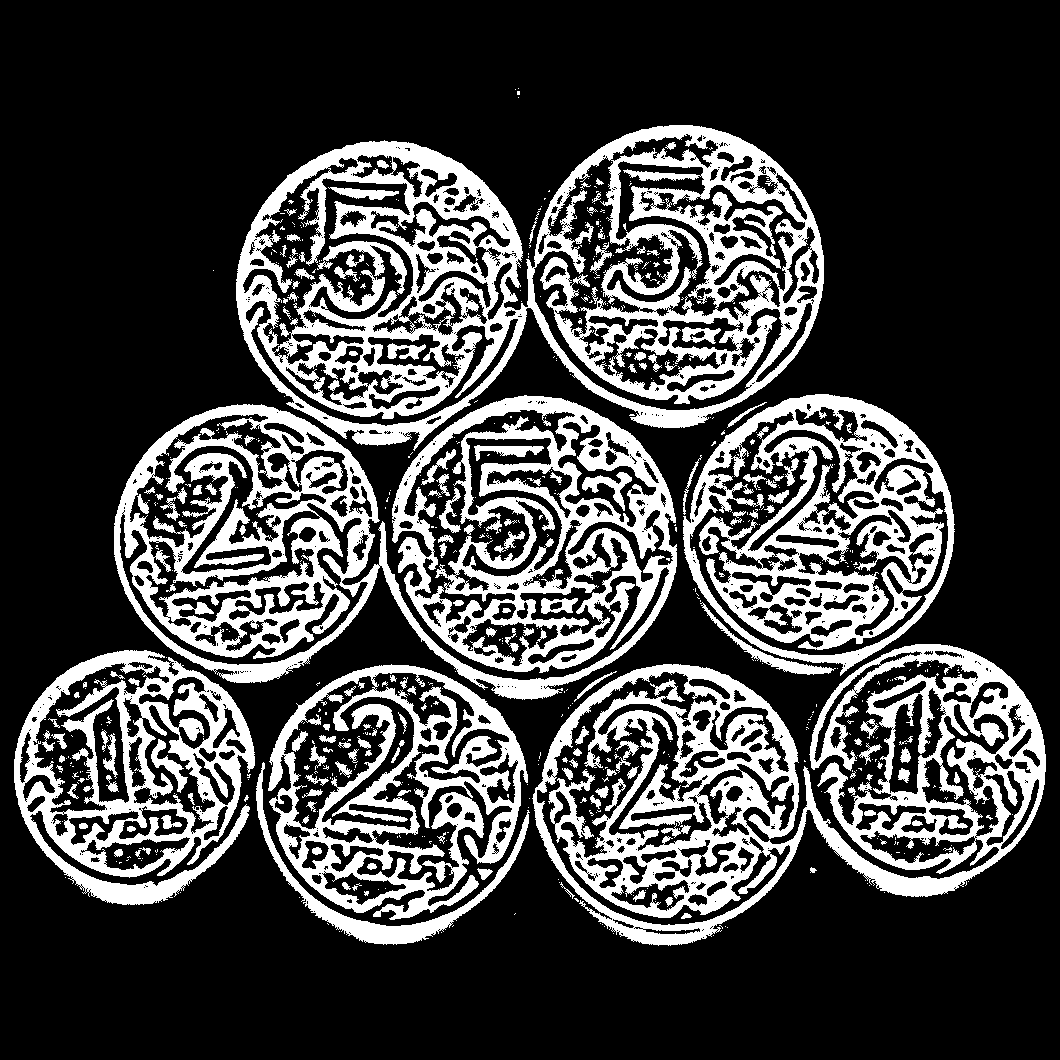

In [ ]:
cv2_imshow(binary)

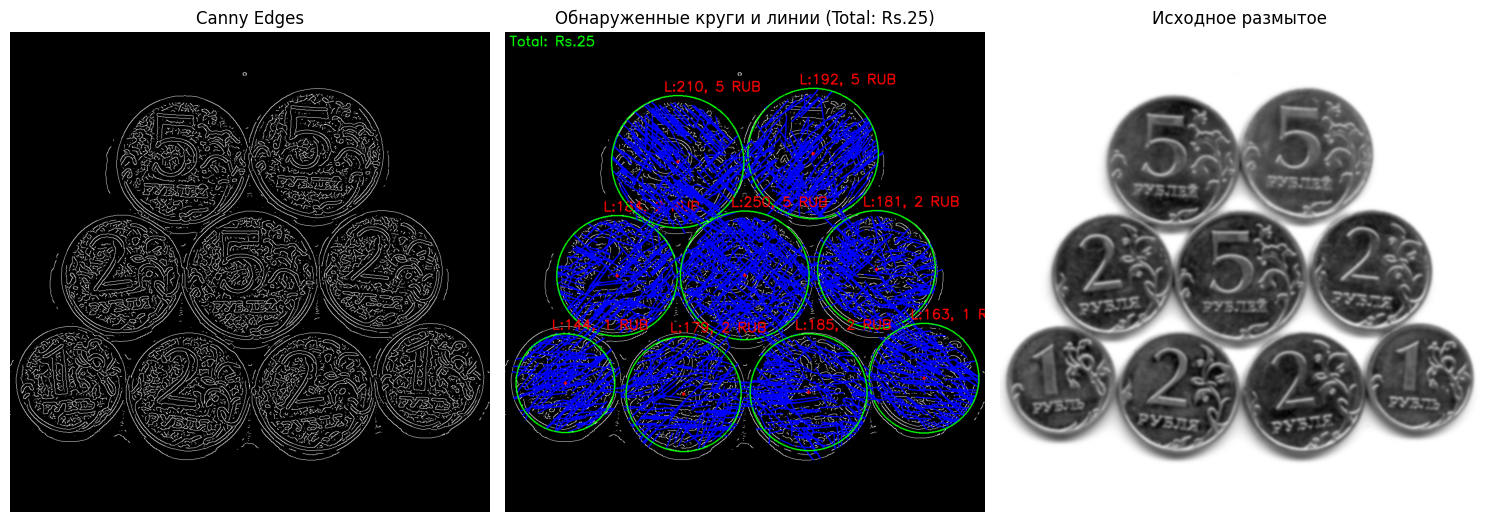

In [ ]:
def my_func(image):
    # Преобразование в градации серого
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    # Размытие изображения для уменьшения шума
    gray_blurred = cv.GaussianBlur(gray, (15, 15), 0)

    # Параметры для функции HoughCircles
    dp = 1.2
    minDist = 125
    param1 = 50
    param2 = 165
    minRadius = 20
    maxRadius = 250

    # Обнаружение кругов
    circles = cv.HoughCircles(gray_blurred, cv.HOUGH_GRADIENT, dp, minDist,
                              param1=param1, param2=param2,
                              minRadius=minRadius, maxRadius=maxRadius)

    # Создание копии изображения для отображения результатов
    img_circles = image.copy()

    edges = cv.Canny(gray_blurred, 50, 100, apertureSize=7)
    lines = cv.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=30,
        maxLineGap=10
    )

    # Создаём копию для визуализации
    img_result = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # Счётчики линий в кругах и сумма денег
    circle_line_counts = []
    totalMoney = 0

    if circles is not None:
        circles = np.uint16(np.around(circles))
        for i, circle in enumerate(circles[0, :]):
            center = (circle[0], circle[1])
            radius = circle[2]
            count = 0

            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    # Центр отрезка
                    mid_x = (x1 + x2) / 2
                    mid_y = (y1 + y2) / 2

                    # Расстояние от центра отрезка до центра круга
                    dist = np.sqrt((mid_x - center[0])**2 + (mid_y - center[1])**2)

                    # Если центр отрезка внутри круга — считаем линию "в круге"
                    if dist <= radius:
                        count += 1
                        # Рисуем линию внутри круга
                        cv.line(img_result, (x1, y1), (x2, y2), (255, 0, 0), 2)

            circle_line_counts.append(count)

            # Классификация монет по количеству линий
            if count <= 163:
                denomination = "1 RUB"
                totalMoney += 1
            elif count >= 192:
                denomination = "5 RUB"
                totalMoney += 5
            else:
                denomination = "2 RUB"
                totalMoney += 2

            # Отрисовка круга
            cv.circle(img_result, center, radius, (0, 255, 0), 2)
            cv.circle(img_result, center, 2, (0, 0, 255), 3)

            # Отрисовка текста с количеством линий и номиналом
            cv.putText(
                img_result,
                f'L:{count}, {denomination}',
                (center[0] - 30, center[1] - radius - 10),
                cv.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 0, 255),
                2
            )

        # Отрисовка общей суммы
        cv.putText(
            img_result,
            f'Total: Rs.{totalMoney}',
            (10, 30),
            cv.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 255, 0),
            2
        )

        return edges, img_result, gray_blurred, totalMoney
    else:
        print("Круги не найдены")
        return edges, img_result, gray_blurred, totalMoney

# Вызов функции
edges, img_result, gray_blurred, totalMoney = my_func(image)

# Визуализация
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title(f'Обнаруженные круги и линии (Total: Rs.{totalMoney})')
plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Исходное размытое')
plt.imshow(gray_blurred, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
kernel = np.ones((3, 3), np.uint8)
closing = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel, iterations=4)

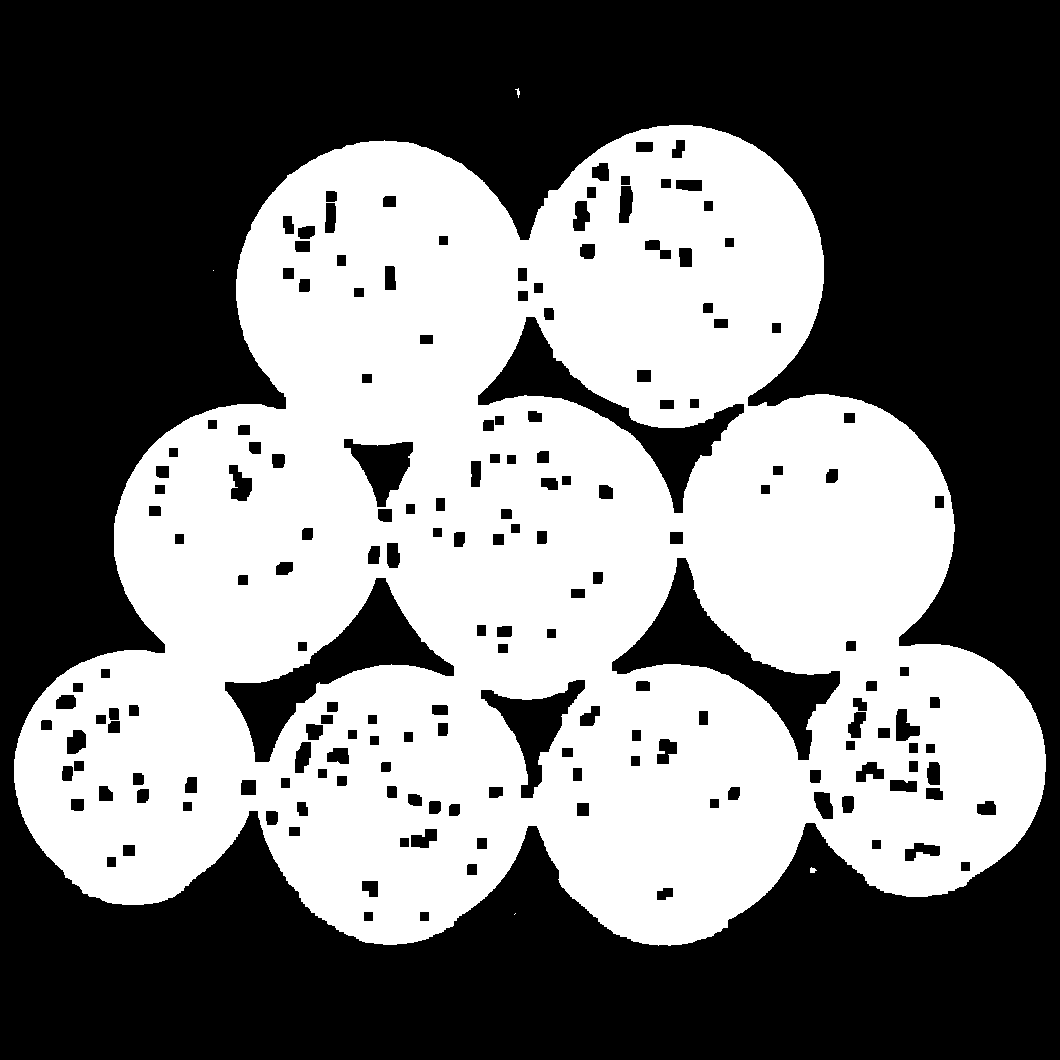

In [ ]:
cv2_imshow(closing)

In [ ]:

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def find_coins(path: str):
    # Загрузка изображения
    img = cv.imread(path)
    if img is None:
        print("Ошибка: изображение не загружено. Изображение не найдено или указан неверный путь")
        return

    # Преобразование в градации серого
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Улучшение контрастности с использованием CLAHE
    #clahe = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(8, 8))
    #gray = clahe.apply(gray)

    # Размытие для уменьшения шума
    gray_blurred = cv.medianBlur(gray, 5)

    # Параметры для функции HoughCircles
    dp = 1.2                # Параметр разрешения аккумуляторного массива
    minDist = 125            # Минимальное расстояние между центрами обнаруженных окружностей
    param1 = 50             # Порог для метода Кэнни
    param2 = 165            # Порог для функции HoughCircles (чем меньше, тем больше ложных кругов)
    minRadius = 20         # Минимальный радиус круга
    maxRadius = 250          # Максимальный радиус круга

    # Обнаружение кругов
    circles = cv.HoughCircles(gray_blurred, cv.HOUGH_GRADIENT, dp, minDist,
                               param1=param1, param2=param2,
                               minRadius=minRadius, maxRadius=maxRadius)

    img_circles = img.copy()
    total_amount = 0
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            center = (circle[0], circle[1])
            radius = circle[2]
            # Рисование круга и центра
            cv.circle(img_circles, center, radius, (0, 255, 0), 2)
            cv.circle(img_circles, center, 5, (0, 0, 255), 3)

        for circle in circles[0, :]:
            radius = circle[2]
            print(radius)
            if radius > 90 and radius < 120:
              nom = 1
            elif radius > 120 and radius < 135:
              nom = 2
            elif radius > 135:
              nom = 5
            total_amount += nom
            cv.putText(img_circles, f"{nom} руб.",
                        (circle[0]-20, circle[1]-20),
                        cv.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)
            cv.putText(img_circles, f"R={radius}",
                        (circle[0]-20, circle[1]+40),
                        cv.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)
        print(f"Общая сумма монет: {total_amount}₽")
        cv.putText(img_circles, f"Сумма: {total_amount} руб.",
                    (20, 70), cv.FONT_HERSHEY_COMPLEX, 1.5, (0, 0, 255), 2)
    else:
        print("Круги не найдены")

    # Отображение результатов
    plt.figure(figsize=(18, 12))
    plt.subplot(1, 2, 1)
    plt.title('Градации серого с CLAHE')
    plt.imshow(gray_blurred, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Обнаруженные круги (монеты)')
    plt.imshow(cv.cvtColor(img_circles, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

148
133
146
132
136
131
119
125
116
Общая сумма монет: 25₽


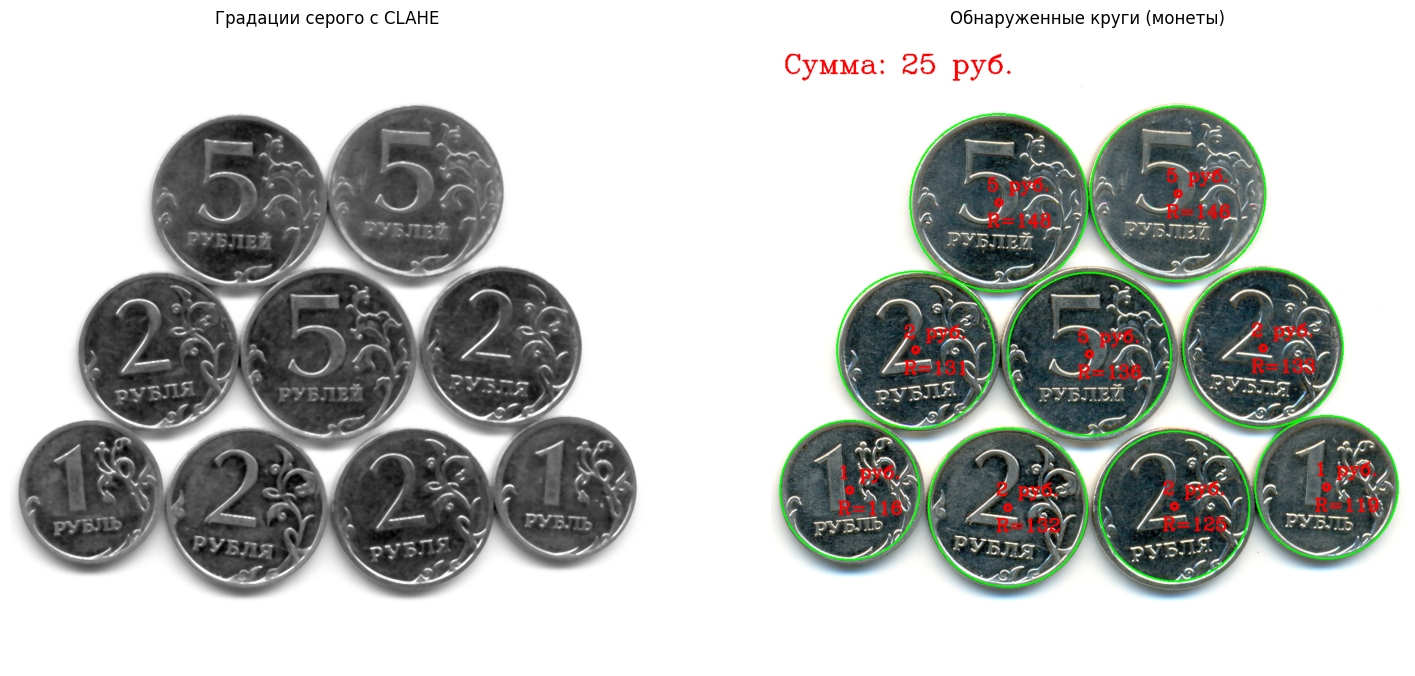

In [ ]:
find_coins(image_path1)

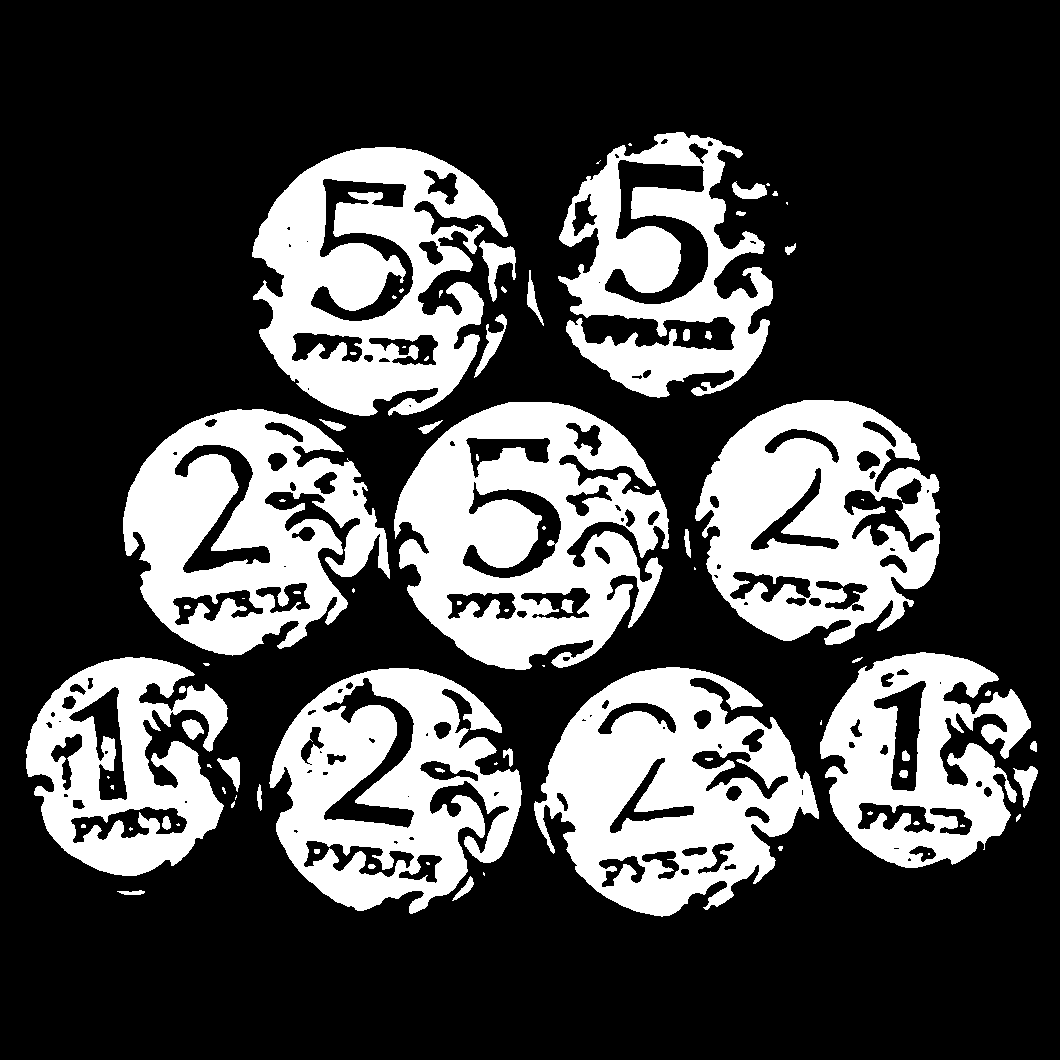

In [ ]:
# Дополнительно: чисто чёрно-белое изображение (бинарное)
gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# gray_blurred = cv.medianBlur(gray, 5)
gray_blurred = cv.GaussianBlur(gray, (15, 15), 0)
blurred = cv.GaussianBlur(gray, (11, 11), 0)

binary = cv.threshold(blurred,  90, 255, cv.THRESH_BINARY_INV)[1]
# _, thresh = cv2.threshold(blurred, 85, 255, cv2.THRESH_BINARY_INV)
# edged = cv.Canny(gray_blurred, 30, 50)

inver = cv.bitwise_not(binary)

cv2_imshow(binary)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import widgets
from IPython.display import display
from ipywidgets import interact, IntSlider, Dropdown

# === Предположим, у тебя есть бинарное изображение: binary
# binary = ...
digit_mask = None
def apply_morphology_and_extract_digits(kernel_size, iterations, morph_shape_idx):
    global digit_mask  # <-- Делаем digit_mask глобальной
    # Словарь для выбора формы ядра
    morph_shapes = {
        0: cv2.MORPH_RECT,
        1: cv2.MORPH_ELLIPSE,
        2: cv2.MORPH_CROSS
    }
    kernel_shape = morph_shapes[morph_shape_idx]

    # Создаём ядро
    kernel = cv2.getStructuringElement(kernel_shape, (kernel_size, kernel_size))

    # Применяем закрытие
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=iterations)

    # Находим контуры на закрытом изображении
    contours, hierarchy = cv2.findContours(closed, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Создаём маску для цифр
    digit_mask = np.zeros_like(binary)

    # Проходим по контурам
    for i, cnt in enumerate(contours):
        # Если контур имеет родителя (т.е. является внутренним — дыркой)
        if hierarchy[0][i][3] != -1:
            # Это дырка — возможно, часть цифры
            cv2.drawContours(digit_mask, [cnt], -1, 255, -1)

    # Также можно добавить внешние контуры, если они маленькие (цифры)
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if ((area < 500) and (area > 400)) and hierarchy[0][i][3] == -1:  # Маленький внешний контур — вероятно, цифра
            cv2.drawContours(digit_mask, [cnt], -1, 255, -1)

    # === Вырезаем цифры из binary ===
    extracted_digits = cv2.bitwise_and(binary, digit_mask)

    # Визуализируем
    plt.figure(figsize=(32, 12))

    plt.subplot(1, 4, 1)
    plt.title("Original Binary")
    plt.imshow(binary, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title("Filled Contours")
    plt.imshow(closed, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title("Digit Mask (Internal Contours)")
    plt.imshow(digit_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Extracted Digits")
    plt.imshow(extracted_digits, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# === Интерактивные ползунки ===
interact(
    apply_morphology_and_extract_digits,
    kernel_size=IntSlider(value=3, min=1, max=15, step=2, description="Kernel Size:"),
    iterations=IntSlider(value=1, min=1, max=10, description="Iterations:"),
    morph_shape_idx=Dropdown(
        options=[(name, idx) for idx, name in enumerate(['RECT', 'ELLIPSE', 'CROSS'])],
        value=0,
        description='Morph Shape:'
    )
)

interactive(children=(IntSlider(value=3, description='Kernel Size:', max=15, min=1, step=2), IntSlider(value=1…

<function __main__.apply_morphology_and_extract_digits(kernel_size, iterations, morph_shape_idx)>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import widgets
from IPython.display import display
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

# === Предположим, у тебя есть бинарное изображение: binary
# binary = ...  # Убедись, что это бинарное изображение (0 и 255)

def apply_morphology_and_extract_digits(kernel_size, iterations, morph_shape_idx,
                                       min_aspect_ratio, max_aspect_ratio, min_compactness,
                                       min_area_filter):
    global digit_mask
    # Словарь для выбора формы ядра
    morph_shapes = {
        0: cv2.MORPH_RECT,
        1: cv2.MORPH_ELLIPSE,
        2: cv2.MORPH_CROSS
    }
    kernel_shape = morph_shapes[morph_shape_idx]

    # Создаём ядро
    kernel = cv2.getStructuringElement(kernel_shape, (kernel_size, kernel_size))

    # Применяем закрытие и открытие
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, hierarchy = cv2.findContours(opened, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    digit_contours = []
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if area < min_area_filter:  # Фильтр минимальной площади
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / float(h)
        compactness = 4 * np.pi * area / (cv2.arcLength(cnt, True) ** 2 + 1e-5)

        # фильтры формы
        if not (min_aspect_ratio < aspect_ratio < max_aspect_ratio):
            continue
        # if compactness < min_compactness:
        #     continue

        # фильтры иерархии
        is_internal = hierarchy[0][i][3] != -1
        is_small_external = (hierarchy[0][i][3] == -1) and (area < 800)

        if is_internal or is_small_external:
            digit_contours.append(cnt)


    if len(digit_contours) == 0:
        print("Нет подходящих контуров")
        digit_mask = np.zeros_like(binary)
    else:
        # Считаем среднюю площадь
        areas = [cv2.contourArea(cnt) for cnt in digit_contours]
        avg_area = np.mean(areas)

        # Оставляем только контуры с площадью > средней
        large_contours = [cnt for cnt in digit_contours if cv2.contourArea(cnt) > avg_area]

        # Создаём маску для больших контуров
        digit_mask = np.zeros_like(binary)
        cv2.drawContours(digit_mask, large_contours, -1, 255, -1)

    # === Вырезаем цифры из binary ===
    extracted_digits = cv2.bitwise_and(binary, digit_mask)

    # Визуализируем
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 3, 1)
    plt.title("Original Binary")
    plt.imshow(binary, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title(f"Digit Mask (Above Avg Area: {avg_area:.2f})")
    plt.imshow(digit_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Extracted Digits")
    plt.imshow(extracted_digits, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# === Интерактивные ползунки ===
interact(
    apply_morphology_and_extract_digits,
    kernel_size=IntSlider(value=3, min=1, max=15, step=2, description="Kernel Size:"),
    iterations=IntSlider(value=1, min=1, max=10, description="Iterations:"),
    morph_shape_idx=Dropdown(
        options=[(name, idx) for idx, name in enumerate(['RECT', 'ELLIPSE', 'CROSS'])],
        value=0,
        description='Morph Shape:'
    ),
    min_aspect_ratio=FloatSlider(value=0.2, min=0.1, max=1.0, step=0.05, description="Min Aspect Ratio:"),
    max_aspect_ratio=FloatSlider(value=1.5, min=0.5, max=3.0, step=0.05, description="Max Aspect Ratio:"),
    min_compactness=FloatSlider(value=0.2, min=0.0, max=1.0, step=0.05, description="Min Compactness:"),
    min_area_filter=IntSlider(value=200, min=10, max=400, step=5, description="Min Area Filter:")
)

interactive(children=(IntSlider(value=3, description='Kernel Size:', max=15, min=1, step=2), IntSlider(value=1…

<function __main__.apply_morphology_and_extract_digits(kernel_size, iterations, morph_shape_idx, min_aspect_ratio, max_aspect_ratio, min_compactness, min_area_filter)>

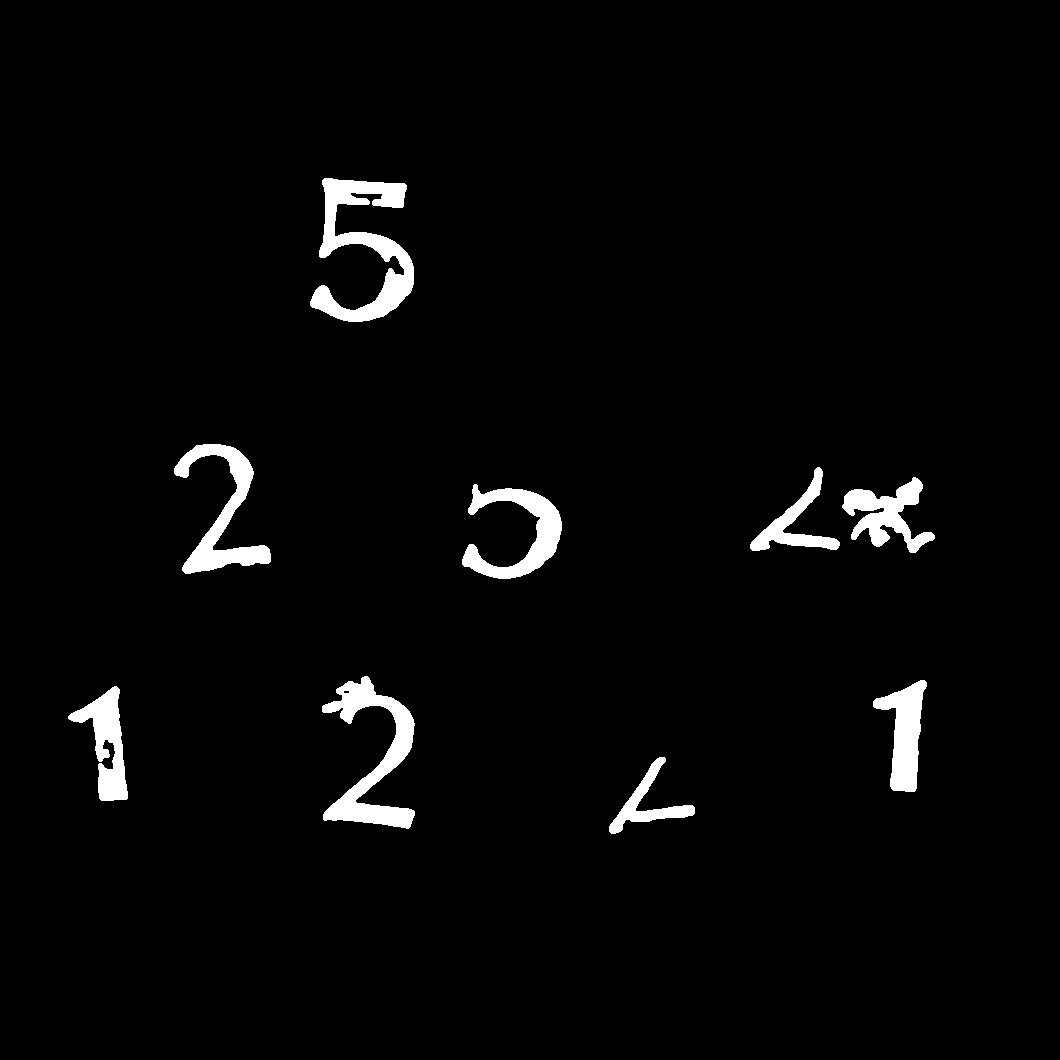

In [ ]:
cv2_imshow(digit_mask)

In [ ]:
# Ссылка на файл для скачивания
url1 = r'https://otvet.imgsmail.ru/download/269579619_08696fe28f4cbfde3e1ba4b5c8fea44d_800.jpg'

# Скачиваем файл с помощью wget
!wget -O money3.jpg '{url1}'

# Ссылка на файл для скачивания
url2 = r'https://cdn1.ozone.ru/s3/multimedia-1-r/c600/7526734443.jpg'

# Скачиваем файл с помощью wget
!wget -O money4.jpg '{url2}'

--2025-10-26 14:56:35--  https://otvet.imgsmail.ru/download/269579619_08696fe28f4cbfde3e1ba4b5c8fea44d_800.jpg
Resolving otvet.imgsmail.ru (otvet.imgsmail.ru)... 95.163.41.54
Connecting to otvet.imgsmail.ru (otvet.imgsmail.ru)|95.163.41.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34948 (34K) [image/jpeg]
Saving to: ‘money3.jpg’

money3.jpg          100%[===================>]  34.13K  --.-KB/s    in 0s      

2025-10-26 14:56:37 (246 MB/s) - ‘money3.jpg’ saved [34948/34948]

--2025-10-26 14:56:37--  https://cdn1.ozone.ru/s3/multimedia-1-r/c600/7526734443.jpg
Resolving cdn1.ozone.ru (cdn1.ozone.ru)... 185.73.193.119, 185.73.195.116
Connecting to cdn1.ozone.ru (cdn1.ozone.ru)|185.73.193.119|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 114640 (112K) [image/jpeg]
Saving to: ‘money4.jpg’

money4.jpg          100%[===================>] 111.95K   238KB/s    in 0.5s    

2025-10-26 14:56:38 (238 KB/s) - ‘money4.jpg’ saved [114640/114

In [ ]:
image_path3 = 'money3.jpg'
image_path4 = 'money4.jpg'
image_path5 = 'money5.jpg'
image_path6 = 'money6.jpg'

image3 = cv.imread(image_path3)
image4 = cv.imread(image_path4)
image5 = cv.imread(image_path5)
image6 = cv.imread(image_path6)

image_path7 = 'money7.jpg'
image7 = cv.imread(image_path7)

In [ ]:
def enhance_contrast(gray):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# === Функция обработки ===
def process_image(threshold=50, minLineLength=30, maxLineGap=10):
    gray = cv.cvtColor(normalize_image(image1), cv.COLOR_BGR2GRAY)
    gray_blurred = cv.GaussianBlur(gray, (11, 11), 0)

    # Поиск кругов
    dp = 1.2
    minDist = 125
    param1 = 50
    param2 = 165
    minRadius = 20
    maxRadius = 250

    circles = cv.HoughCircles(gray_blurred, cv.HOUGH_GRADIENT, dp, minDist,
                              param1=param1, param2=param2,
                              minRadius=minRadius, maxRadius=maxRadius)

    # Поиск линий
    edges = cv.Canny(digit_mask, 50, 100, apertureSize=7)
    lines = cv.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=threshold,
        minLineLength=minLineLength,
        maxLineGap=maxLineGap
    )

    img_result = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    circle_line_counts = []

    # === Рисуем линии и круги ===
    if circles is not None:
        circles = np.uint16(np.around(circles))
        for circle in circles[0, :]:
            center = (circle[0], circle[1])
            radius = circle[2]
            count = 0

            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]

                    # Проверяем, что оба конца линии внутри круга
                    dist1 = np.sqrt((x1 - center[0])**2 + (y1 - center[1])**2)
                    dist2 = np.sqrt((x2 - center[0])**2 + (y2 - center[1])**2)

                    if dist1 <= radius and dist2 <= radius:
                        count += 1
                        cv.line(img_result, (x1, y1), (x2, y2), (255, 0, 0), 2)

            circle_line_counts.append((center, radius, count))
            cv.circle(img_result, center, radius, (0, 255, 0), 2)
            cv.circle(img_result, center, 2, (0, 0, 255), 3)

        # === Рисуем текст поверх ===
        for center, radius, count in circle_line_counts:
            text_x = max(center[0] - 30, 0)
            text_y = max(center[1] - radius - 10, 20)
            cv.putText(
                img_result,
                f'L:{count}',
                (text_x, text_y),
                cv.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 0, 255),
                3,
                cv.LINE_AA
            )

    # === Отображение результата ===
    plt.figure(figsize=(26, 7))
    # plt.subplot(1, 2, 1)
    # plt.title('Canny Edges')
    # plt.imshow(edges, cmap='gray')
    # plt.axis('off')

    plt.subplot(1, 1, 1)
    plt.imshow(cv.cvtColor(img_result, cv.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# === Загрузи сюда изображение ===
# например:
# image = cv.imread('/content/coins.jpg')
# image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
# или используй уже загруженную переменную `image`

# === Ползунки для настройки ===
interact(
    process_image,
    threshold=IntSlider(value=25, min=10, max=200, step=5, description='Threshold'),
    minLineLength=IntSlider(value=10, min=10, max=150, step=5, description='Min Line Len'),
    maxLineGap=IntSlider(value=11, min=1, max=100, step=2, description='Max Line Gap')
)


interactive(children=(IntSlider(value=25, description='Threshold', max=200, min=10, step=5), IntSlider(value=1…

<function __main__.process_image(threshold=50, minLineLength=30, maxLineGap=10)>

In [ ]:
# import os
# import requests
# from tqdm.notebook import tqdm

# def download_images(image_links, save_dir):
#     """
#     Скачивает изображения из списка ссылок в указанную папку.

#     Parameters:
#         image_links (list): список URL изображений
#         save_dir (str): путь к папке для сохранения (например, '/content/coins/1rub')
#     """
#     os.makedirs(save_dir, exist_ok=True)

#     for i, url in enumerate(tqdm(image_links, desc=f"Скачивание в {save_dir}")):
#         try:
#             response = requests.get(url, timeout=15)
#             if response.status_code == 200:
#                 file_ext = os.path.splitext(url.split("?")[0])[1]
#                 if file_ext.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
#                     file_ext = ".jpg"  # безопасное расширение по умолчанию
#                 file_path = os.path.join(save_dir, f"coin_{i+1}{file_ext}")
#                 with open(file_path, "wb") as f:
#                     f.write(response.content)
#             else:
#                 print(f"⚠️ Не удалось скачать {url} (код {response.status_code})")
#         except Exception as e:
#             print(f"❌ Ошибка при загрузке {url}: {e}")

#     print(f"✅ Скачано {len(image_links)} изображений в {save_dir}")


# # === Пример использования ===

# # 🔹 Ссылки для каждой категории
# rub1_links = [
#     "https://u.9111s.ru/uploads/202109/19/cd77f9c3a90feb5e673ea195fa009f66.jpg",
#     "https://static.insales-cdn.com/images/products/1/1332/924853556/MRR02231__1_.JPG",
#     "https://coins.su/forum/uploads/2016/05/31/post-42700-0-30577300-1464720757.jpg",
#     "https://numizm.at/upload/cache_images/registered/65/47/654765/654765_658_605.jpg",
#     "https://static.auction.ru/offer_images/2016/11/06/03/big/L/LVWA9iahbxt/1_rubl_2014_mmd_brak_polnyj_raskol.jpg",
#     "https://static.auction.ru/offer_images/rd48/2021/01/02/01/big/Q/QFUzESdsk4K/1_rubl_2016_goda_mmd_m_novyj_gerb.jpg",
#     "https://s5-gallery.aystatic.by/650/819/56/5038/5038056819_1.jpg",
#     "https://cache3.youla.io/files/images/720_720_out/5e/64/5e64ac83c15ae35a7942fcf6.jpg",
#     "https://static.auction.ru/offer_images/rd48/2020/12/24/02/big/T/tYFYN8EtoPe/moneta_rossii_1_rub_2013_g_mmd_brak.jpg"
# ]

# rub2_links = [
#     "https://coinsmoscow.ru/published/publicdata/COINSSR2WEBASYSTT/attachments/SC/products_pictures/23262-2rDvoenie_2_enl.jpg",
#     "https://cache3.youla.io/files/images/780_780/5b/e2/5be2bb95cf689a6eef17c827.jpg",
#     "https://meshok.net/i/33638483.0.208x208.jpg",
#     "https://s1-gallery.aystatic.by/650/30/380/5033/5033380030_0.jpg",
#     "https://static.auction.ru/offer_images/rd48/2024/04/05/06/big/2/2aMaq1uQV9I/2_rublja_2010_spmd_sht_4_22_redkij_redkie_monety.jpg",
#     "https://static.auction.ru/offer_images/2018/04/08/06/big/7/7i99IYSBJmi/2_rublja_2013_mmd_brak.jpg",
#     "https://static.auction.ru/offer_images/cmn8/2019/02/18/02/big/W/wnqIoiTUdgN/2_r_2013g_mmd_polnyj_raskol.jpg",
#     "https://meshok.net/i/321071767.0.208x208.jpg",
#     "https://static.auction.ru/offer_images/rd48/2021/03/13/10/big/N/nsiuRUdB97k/2_rublja_2019_m_sht_b2_nechastaja_moneta.jpg",
#     "https://cache3.youla.io/files/images/720_720_out/5d/d3/5dd3b3839380008679069e24.jpg"
# ]

# rub5_links = [
#     "http://aeol.su/sites/default/files/user_images/Newbie/coin_2_r.jpg",
#     "http://aeol.su/sites/default/files/user_images/Федор13/dsc04410.jpg",
#     "https://static.auction.ru/offer_images/2017/08/22/07/big/E/eap6cS4uCdm/5_rublej_2010_mmd_raznovid_b1.jpg",
#     "https://static.auction.ru/offer_images/rd48/2020/11/14/01/big/6/6ayAKYTtEvm/5_rublej_2012_goda_mmd_sht_n_5_42_1_ja_shtempelnaja_para_po_a_s.jpg",
#     "https://pirkis.lt/images/prekes/16369000/16369957/20180107_131502.jpg",
#     "https://static.auction.ru/offer_images/2018/01/21/08/big/D/dxx7BOCe3R7/5_rublej_1998_spmd_goda.jpg",
#     "https://static.auction.ru/offer_images/2016/05/24/08/big/3/3UTSFZPGsJ2/2014_5_rublej_mmd_2014.jpg",
#     "https://auck.ru/upload/iblock/1be/fkigqfpa2y3x3mul68ofbgozkrtyq111.JPG",
#     "https://static.auction.ru/offer_images/rd48/2023/03/10/03/big/Z/ZJbYR9OUM5E/rossija_5_rublej_2019_mmd.jpg",
#     "https://meshok.net/i/103950718.0.208x208.jpg"
# ]

# # 🔹 Базовая папка
# base_dir = "/content/coins"

# # 🔹 Скачиваем по номиналам
# download_images(rub1_links, os.path.join(base_dir, "1rub"))
# download_images(rub2_links, os.path.join(base_dir, "2rub"))
# download_images(rub5_links, os.path.join(base_dir, "5rub"))
